# lab 1: generator de text caracter cu caracter cu lstm

scopul lucrării: să construim o rețea lstm care învață dintr-un text și apoi scrie text nou, literă cu literă.

modelul primește o secvență de caractere și ghicește caracterul următor. repetăm acest pas de multe ori și obținem un text întreg.

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

## 1. corpusul de text

folosim un text de nietzsche în limba engleză. luăm doar primele 200 000 de caractere, ca antrenarea să fie rapidă.

modelul nu știe nimic despre cuvinte sau gramatică. el vede doar un șir lung de caractere.

In [3]:
path = keras.utils.get_file(
        "nietzsche.txt",
    origin="https://s3.amazonaws.com/text-datasets/nietzsche.txt"
)
text = open(path, encoding="utf-8").read()[:200_000]

print("Characters in corpus:", len(text))
print(text[:300])

Characters in corpus: 200000
PREFACE


SUPPOSING that Truth is a woman--what then? Is there not ground
for suspecting that all philosophers, in so far as they have been
dogmatists, have failed to understand women--that the terrible
seriousness and clumsy importunity with which they have usually paid
their addresses to Truth, ha


## 2. vocabularul și codificarea

o rețea neuronală lucrează doar cu numere. de aceea fiecare caracter diferit primește un număr propriu.

facem două dicționare: unul transformă caracterul în număr, altul transformă numărul înapoi în caracter.

In [4]:
chars = sorted(set(text))
vocab_size = len(chars)
char2idx = {c: i for i, c in enumerate(chars)}
idx2char = np.array(chars)

encoded = np.array([char2idx[c] for c in text], dtype=np.int32)

print("Vocabulary size:", vocab_size)
print("First 20 ids:", encoded[:20])

Vocabulary size: 78
First 20 ids: [38 40 27 28 23 25 27  0  0  0 41 43 38 38 37 41 31 36 29  1]


## 3. exemplele de antrenare

tăiem textul în bucăți de câte 101 caractere.

* x sunt primele 100 de caractere din bucată
* y este aceeași bucată, dar mutată cu un caracter la dreapta

așa, pentru fiecare poziție, modelul învață care caracter vine după. apoi amestecăm bucățile și le grupăm în loturi de câte 64.

In [5]:
SEQ_LEN = 100
BATCH = 64

ds = tf.data.Dataset.from_tensor_slices(encoded)
ds = ds.batch(SEQ_LEN + 1, drop_remainder=True)
ds = ds.map(lambda w: (w[:-1], w[1:]))
ds = ds.shuffle(10_000).batch(BATCH, drop_remainder=True).prefetch(tf.data.AUTOTUNE)

for x, y in ds.take(1):
    print("x:", "".join(idx2char[x[0].numpy()])[:60])
    print("y:", "".join(idx2char[y[0].numpy()])[:60])

x: ng that "stood fast" of the earth--the belief in "substance,
y: g that "stood fast" of the earth--the belief in "substance,"


## 4. modelul

modelul are trei straturi:

* Embedding transformă numărul fiecărui caracter într-un vector mic
* LSTM citește secvența și păstrează o memorie despre ce a văzut înainte
* Dense dă un scor pentru fiecare caracter posibil care poate urma

return_sequences=True face ca lstm să dea un rezultat la fiecare poziție, nu doar la ultima. astfel modelul învață din toate pozițiile odată.

ca funcție de pierdere folosim SparseCategoricalCrossentropy. ea arată cât de greșit ghicește modelul caracterul următor.

In [6]:
model = keras.Sequential([
    layers.Embedding(vocab_size, 64),
    layers.LSTM(256, return_sequences=True),
    layers.Dense(vocab_size),
])
model.compile(
    optimizer="adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 5. antrenarea

corpusul este mic, așa că facem doar 20 de epoci.

după antrenare desenăm graficul pierderii. dacă linia scade, modelul învață.

In [7]:
history = model.fit(ds, epochs=20)

Epoch 1/20


C:\Users\Vica\PycharmProjects\slm_llm\big_data\lab_1\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 135ms/step - loss: 3.4199
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 139ms/step - loss: 3.0257
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 144ms/step - loss: 2.7579
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 135ms/step - loss: 2.6024
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step - loss: 2.5103
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 136ms/step - loss: 2.4342
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 146ms/step - loss: 2.3777
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 139ms/step - loss: 2.3289
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 149ms/step - loss: 2.2872
Epoch 10/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 291ms/step - loss: 2.2494
Epoch 11/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 302ms/step - loss: 2.2144
Epoch 12/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 285ms/step - loss: 2.1852
Epoch 13/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 290ms/step - loss: 2.1563
Epoch 14/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 304ms/step - loss: 2.1275
Epoch 15/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 290ms/step - loss: 2.1012

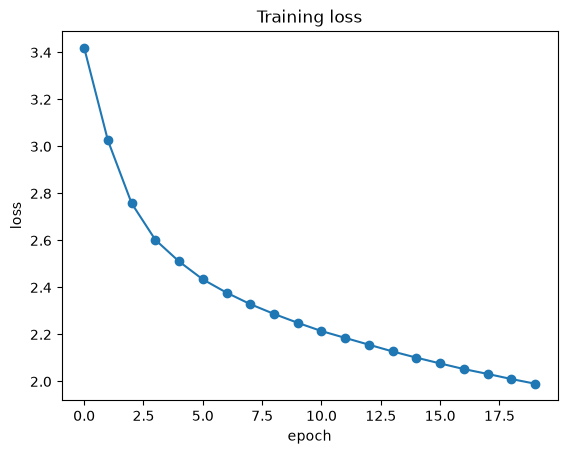

In [8]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], marker="o")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("Training loss")
plt.show()

## 6. generarea textului

generarea merge într-o buclă:

1. dăm modelului textul de început
2. luăm scorurile pentru ultima poziție
3. alegem la întâmplare un caracter, după aceste scoruri
4. îl adăugăm la text și repetăm

parametrul temperature controlează cât de riscant alege modelul:

* valoare mică: textul este sigur, dar se repetă
* valoare mare: textul este mai variat, dar are multe greșeli

mai jos încercăm trei valori: 0.5, 1.0 și 0.1.

In [9]:
def generate(seed, length=400, temperature=0.8):
    ids = [char2idx[c] for c in seed]
    for _ in range(length):
        x = np.array(ids[-SEQ_LEN:])[None, :]
        logits = model(x, training=False)[0, -1].numpy() / temperature
        probs = np.exp(logits - logits.max())
        probs /= probs.sum()
        ids.append(int(np.random.choice(vocab_size, p=probs)))
    return "".join(idx2char[ids])

print(generate("The origin of our concept of knowledge ", temperature=0.5))

The origin of our concept of knowledge it perasel wish in the man of the will of and hen with the hare he scupe spince some his of the praiding, and gerosting to a mor the it one which the the whould the sele of not it instarself to indires and
ancention in the mant the preract to mas to hat evere or the selless of the man mene and more and sucher a wist conspestion of hais nefferers in the santers of the call is the sumpelf whis the s


In [10]:
print(generate("The origin of our concept of knowledge ", temperature=1.0))

The origin of our concept of knowledge as thim
thetrered protan now abos an thait itsuph, livel
imE oretely wOt thuchorelvent futher lis!.. Math tored vice sy mevising
toythly, have ond posssinnce profabjed, estertues; hy gomail and the caim,
and lobos to disceing mocely mand eqedeg to that sleeffinte: and egrandy itsold," mas for and belalaby their intructuf, lofide to himphencle, fore uplatious fis now the hif stosman-sonet of Astiou


In [11]:
print(generate("The origin of our concept of knowledge ", temperature=0.1))

The origin of our concept of knowledge of the soment of the prostion of the sould the sould the some the sould the some the some the some and sould the soment of the soment of the sould the sould and soment of the some the sould the sencersing the sould the soment of the senters of the sentertion of the senters of the sould the some of the such the sould the sould the sould the soment of the sould the soment of the sould the some the s


## 7. evaluarea calității generării și interpretarea rezultatelor

pierderea. la început pierderea era 3.44. după 20 de epoci a scăzut la 1.95. deci modelul a învățat destul de bine care caractere vin de obicei unul după altul.

temperatura 0.5. textul arată ca engleza. apar cuvinte reale, ca the, will, danger, man. unele cuvinte sunt inventate, iar propozițiile nu au sens.

temperatura 1.0. textul devine haotic. apar multe cuvinte greșite, litere mari fără motiv și semne ciudate.

temperatura 0.1. modelul alege mereu varianta cea mai sigură. de aceea se blochează și repetă aceeași frază: the self the self.

cel mai bun rezultat se obține la o temperatură medie, în jur de 0.5.

## 8. concluzii

* lstm poate învăța structura unui text doar din caractere, fără să știe ce este un cuvânt.
* după o antrenare scurtă modelul scrie cuvinte simple și respectă spațiile și punctuația.
* textul încă nu are sens, pentru că modelul este mic și a văzut puțin text.
* temperatura schimbă mult rezultatul: prea mică duce la repetiții, prea mare duce la haos.
* rezultatul ar fi mai bun cu mai mult text, mai multe epoci sau mai multe straturi lstm.